# ⚛️ Fusion Equilibrium Challenge — Exploratory Data Analysis

An interactive walkthrough of the dataset behind the [Fusion Equilibrium Challenge](https://github.com/Sophelio/fusion-equilibrium-challenge-starter):
reconstruct the 2-D poloidal flux map ψ(R,Z) of a tokamak plasma **without magnetic sensors** — from coil currents (actuators)
and Thomson-scattering kinetic profiles only. Zero-shot transfer to a second machine (MAST) is the cross-machine challenge.

This notebook uses the six **local demo shots** in `parquet_data/` (3 × DIII-D + 3 × MAST) so it runs entirely offline.
The full training set (7,041 DIII-D shots with labels) streams from Hugging Face:

```python
from datasets import load_dataset
train = load_dataset("Sophelio/fusion-equilibrium-challenge", "diii_d_train", split="train", streaming=True)
row = next(iter(train))
```

For every feature group we cover: **what it is**, **what it looks like**, and **how you would use it as a model input**.


## 0. Setup

Read the six demo shots. Each parquet file is **one shot = one row**, and every time-series / 2-D map is a *nested array* inside that row.

**Colab:** the demo shots live in `parquet_data/` (Git LFS). The cell below clones the starter repo and
`git lfs pull`s them when they are missing — so this notebook runs on a fresh Colab runtime with no manual steps.
On a local checkout (files already present) it is a no-op. If you have already run
`Fusion_Equilibrium_Challenge_Colab.ipynb` in this Colab runtime, the repo is already at `/content/fusion-equilibrium-challenge-starter` and this cell just reuses it.


In [1]:

import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/Sophelio/fusion-equilibrium-challenge-starter"
REPO_DIR = "/content/fusion-equilibrium-challenge-starter"
MIN_REAL_SIZE = 100_000  # real parquet shots are multi-MB; LFS pointers are ~130 bytes

def demo_shots_ready(root: Path) -> bool:
    d = root / "parquet_data"
    files = list(d.glob("*.parquet")) if d.exists() else []
    return any(f.is_file() and f.stat().st_size > MIN_REAL_SIZE for f in files)

if not demo_shots_ready(Path(".")):
    if Path(REPO_DIR).exists() and demo_shots_ready(Path(REPO_DIR)):
        os.chdir(REPO_DIR)
        print("Using repo already cloned at", REPO_DIR)
    else:
        if not Path(REPO_DIR).exists():
            print("Cloning starter repo...")
            subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
        os.chdir(REPO_DIR)
        print("Installing git-lfs and pulling demo shots...")
        subprocess.run(["git", "lfs", "install"], check=True)
        subprocess.run(["git", "lfs", "pull"], check=True)
print("Working dir:", os.getcwd())
print("Demo shots:", [p.name for p in sorted(Path("parquet_data").glob("*.parquet"))])


Working dir: /Users/rimma/Documents/vibe-coding/August2026/fusion-equilibrium-challenge-starter
Demo shots: ['d3d_shot_203702.parquet', 'd3d_shot_203703.parquet', 'd3d_shot_203704.parquet', 'mast_shot_28348.parquet', 'mast_shot_28350.parquet', 'mast_shot_28351.parquet']


In [2]:

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

plt.rcParams["figure.dpi"] = 100

PARQUET_DIR = Path("parquet_data")

def stack_psirz(raw):
    """efit_psirz -> (T, 65, 65) float32, handling the object-array layouts parquet returns."""
    try:
        a = np.asarray(raw, dtype=np.float32)
        if a.ndim == 3:
            return a
    except (ValueError, TypeError):
        pass
    return np.stack([np.stack([np.asarray(r, dtype=np.float32) for r in grid]) for grid in raw])

def stack_profiles(obj):
    """Object array of per-time channel arrays -> (T, n_channels)."""
    return np.stack([np.asarray(x, dtype=np.float32) for x in obj])

def load_demo_shots():
    shots = {}
    for p in sorted(Path(PARQUET_DIR).glob("*.parquet")):
        shots[p.stem] = pd.read_parquet(p).iloc[0]
    return shots

shots = load_demo_shots()
print("Demo shots:", list(shots))
d3d = shots["d3d_shot_203702"]      # DIII-D
mast = shots["mast_shot_28348"]     # MAST


Demo shots: ['d3d_shot_203702', 'd3d_shot_203703', 'd3d_shot_203704', 'mast_shot_28348', 'mast_shot_28350', 'mast_shot_28351']


## 1. Anatomy of one shot

The two machines share the same *schema* — the columns differ. Here is the full column inventory for one DIII-D and one MAST shot.

| Group | DIII-D | MAST |
|---|---|---|
| **Target** | `efit_psirz` (T,65,65), `efit_times`, grid | same (demo shots only) |
| **EFIT scalars** | `efit_q95`, `efit_beta_n`, `efit_li`, `efit_r_axis`, `efit_z_axis` | same + extra |
| **Magnetics** | 21 coil-current columns on `magnetics_time` | 14 columns on `magnetics_time` |
| **Thomson** | `thomson_core_*`, `thomson_edge_*` | same |
| **Geometry** | `coil_*` (19 rows), `thomson_chord_*` | `coil_*` (812 rows), `thomson_chord_*` |


In [3]:

def show_columns(row, label):
    print(f"=== {label} ===")
    for col in row.index:
        v = row[col]
        if isinstance(v, np.ndarray):
            print(f"  {col:42s} shape={v.shape} dtype={v.dtype}")
        else:
            print(f"  {col:42s} scalar: {str(v)[:50]}")

show_columns(d3d, "DIII-D demo shot")


=== DIII-D demo shot ===
  source                                     scalar: DIII-D
  efit_times                                 shape=(166,) dtype=float64
  efit_psirz                                 shape=(166,) dtype=object
  magnetics_ECOILA                           shape=(480256,) dtype=float64
  magnetics_F1A                              shape=(480256,) dtype=float64
  magnetics_F1B                              shape=(480256,) dtype=float64
  magnetics_F2A                              shape=(480256,) dtype=float64
  magnetics_F2B                              shape=(480256,) dtype=float64
  magnetics_F3A                              shape=(480256,) dtype=float64
  magnetics_F3B                              shape=(480256,) dtype=float64
  magnetics_F4A                              shape=(480256,) dtype=float64
  magnetics_F4B                              shape=(480256,) dtype=float64
  magnetics_F5A                              shape=(480256,) dtype=float64
  magnetics_F5B       

## 2. The target — the poloidal flux map ψ(R,Z)

`efit_psirz` is a **2-D image per timestep**: 65×65 values of poloidal flux on the fixed `efit_grid_R` / `efit_grid_Z` grid.
It is a "topographic map" of the magnetic bottle:

- **Contours** = magnetic flux surfaces (the surfaces plasma particles follow).
- **Innermost contour** = plasma core (magnetic axis, an O-point).
- **Outermost closed contour** = the last-closed-flux-surface (LCFS) — the plasma boundary.

Everything else the scorer measures (axis location, shape scalars, `li`, boundary) is **derived from your submitted ψ**, so getting this image right is the whole game.

> ⚠️ **Sign convention differs between machines.** On DIII-D the magnetic axis is the **minimum** of ψ; on MAST it is the **maximum**. Both machines run positive plasma current — this is a storage-convention quirk of two different EFIT codes. The scorer normalizes the sign for you.


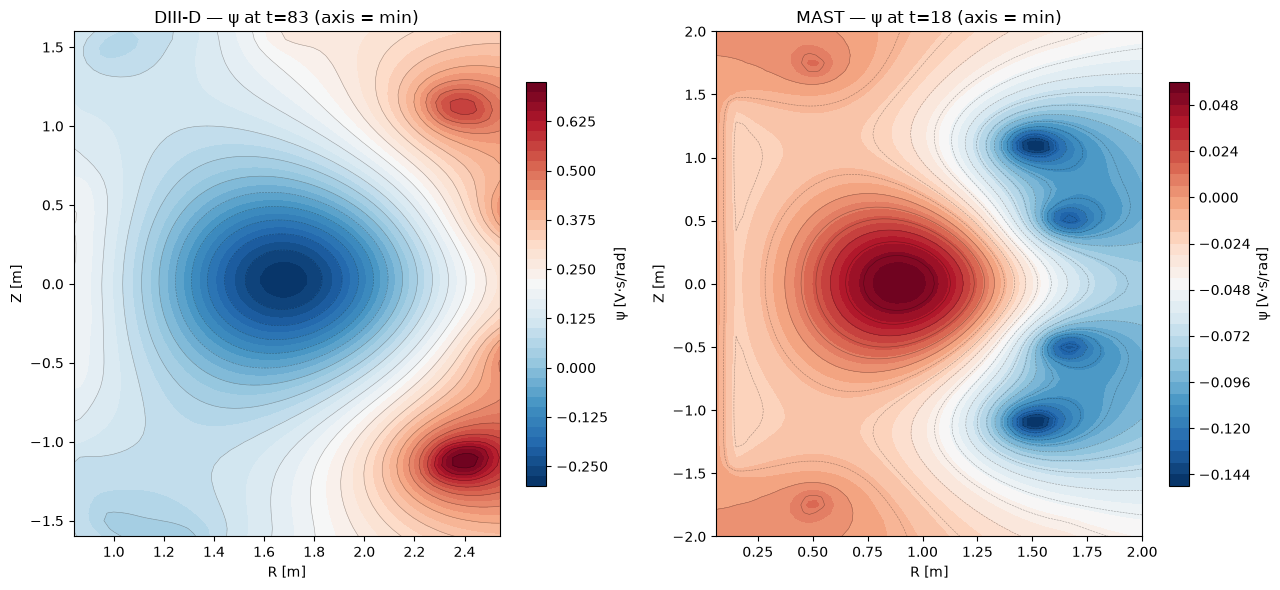

DIII-D frame: magnetic-axis grid cell = (np.int64(33), np.int64(32)) (ψ minimum)
MAST   frame: magnetic-axis grid cell = (np.int64(32), np.int64(28)) (ψ maximum)


In [4]:

psi_d = stack_psirz(d3d["efit_psirz"])       # (T, 65, 65)
psi_m = stack_psirz(mast["efit_psirz"])

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, (psi, grid_R, grid_Z, name) in zip(axes, [
    (psi_d, d3d["efit_grid_R"], d3d["efit_grid_Z"], "DIII-D"),
    (psi_m, mast["efit_grid_R"], mast["efit_grid_Z"], "MAST"),
]):
    mid = psi.shape[0] // 2
    im = ax.contourf(grid_R, grid_Z, psi[mid], levels=40, cmap="RdBu_r")
    ax.contour(grid_R, grid_Z, psi[mid], levels=20, colors="k", linewidths=0.4, alpha=0.35)
    ax.set_title(f"{name} — ψ at t={mid} (axis = " + ("min" if np.argmin(psi[mid].ravel()) else "max") + ")")
    ax.set_xlabel("R [m]"); ax.set_ylabel("Z [m]")
    fig.colorbar(im, ax=ax, label="ψ [V·s/rad]", shrink=0.8)

plt.tight_layout(); plt.show()

# Confirm the sign convention on these demo frames
print("DIII-D frame: magnetic-axis grid cell =", np.unravel_index(np.argmin(psi_d[80]), (65, 65)), "(ψ minimum)")
print("MAST   frame: magnetic-axis grid cell =", np.unravel_index(np.argmax(psi_m[18]), (65, 65)), "(ψ maximum)")


### The LCFS / boundary

`efit_lcfs_r` / `efit_lcfs_z` give the last-closed-flux-surface contour point-by-point (bonus context, train only — **withheld on test**).
It is not a scored target by itself; the scorer extracts the boundary from *your* ψ and compares with a Hausdorff distance.


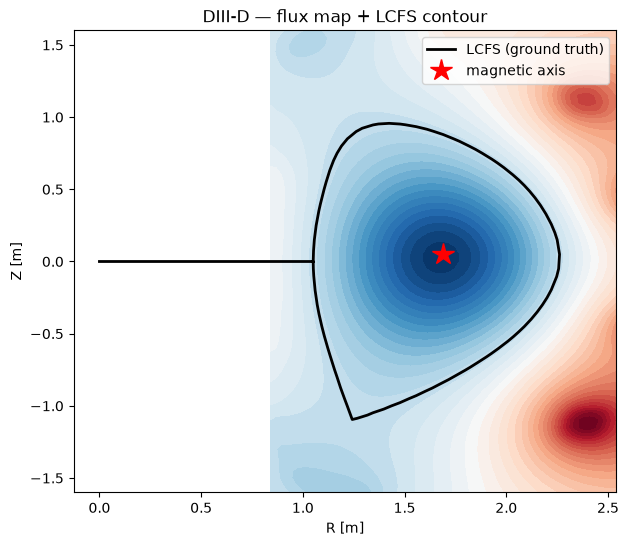

In [5]:

t = 80
fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(d3d["efit_grid_R"], d3d["efit_grid_Z"], psi_d[t], levels=40, cmap="RdBu_r")
ax.plot(d3d["efit_lcfs_r"][t], d3d["efit_lcfs_z"][t], "k-", lw=2, label="LCFS (ground truth)")
ax.plot(d3d["efit_grid_R"][np.unravel_index(np.argmin(psi_d[t]), (65, 65))[1]],
        d3d["efit_grid_Z"][np.unravel_index(np.argmin(psi_d[t]), (65, 65))[0]],
        "r*", ms=16, label="magnetic axis")
ax.set_title("DIII-D — flux map + LCFS contour")
ax.set_xlabel("R [m]"); ax.set_ylabel("Z [m]"); ax.legend()
plt.show()


## 3. EFIT scalar labels

One value per `efit_times` step. Of these, **you submit only `q95` and `betaN`**; the rest are training supervision
(and at scoring time, the axis and `li` are *derived from your submitted ψ* instead).

| Column | What it is | Scored? |
|---|---|---|
| `efit_q95` | safety factor at the 95% flux surface | **submitted** |
| `efit_beta_n` | normalized beta β_N | **submitted** |
| `efit_li` | internal inductance ℓi | derived from ψ at scoring |
| `efit_r_axis` / `efit_z_axis` | magnetic axis R/Z | derived from ψ at scoring |
| `magnetics_dsep` | x-point gap — **EFIT-derived, not an input** | not scored |


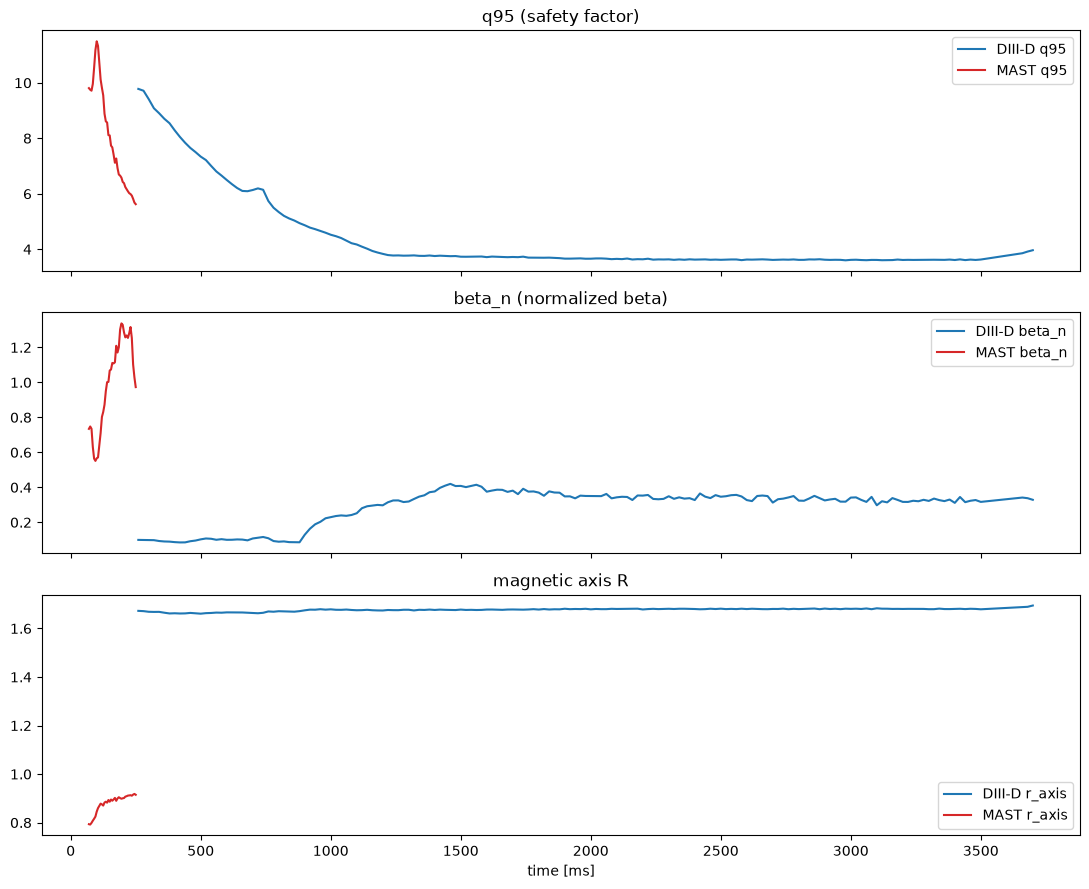

In [6]:

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for (row, label, c) in [(d3d, "DIII-D", "tab:blue"), (mast, "MAST", "tab:red")]:
    t = row["efit_times"]
    axes[0].plot(t, row["efit_q95"], color=c, label=f"{label} q95")
    axes[1].plot(t, row["efit_beta_n"], color=c, label=f"{label} beta_n")
    axes[2].plot(t, row["efit_r_axis"], color=c, label=f"{label} r_axis")

axes[0].set_title("q95 (safety factor)"); axes[1].set_title("beta_n (normalized beta)")
axes[2].set_title("magnetic axis R"); axes[2].set_xlabel("time [ms]")
for a in axes: a.legend()
plt.tight_layout(); plt.show()


## 4. Magnetics — the actuators (DIII-D)

**These are commanded coil currents, not magnetic-field measurements.** That is the point of the challenge: the sensor
suite is withheld. DIII-D has 18 shaping coils (`F1A`…`F9B`, upper/lower) plus the central solenoid `ECOILA` and toroidal
field coil `bcoil`, and the plasma current `magnetics_plasma_current` (Ip) — the *one* legitimate global magnetic scalar you may use.

All are on a shared `magnetics_time` base (here 480,256 samples ≈ 20 kHz over the full ~24 s DAQ window); Ip is on its own ADC at 2 kHz.

> **Units matter.** `magnetics_F*` are **kA·turn** (turn count folded in), `ECOILA`/`bcoil`/`plasma_current` are **kA**.


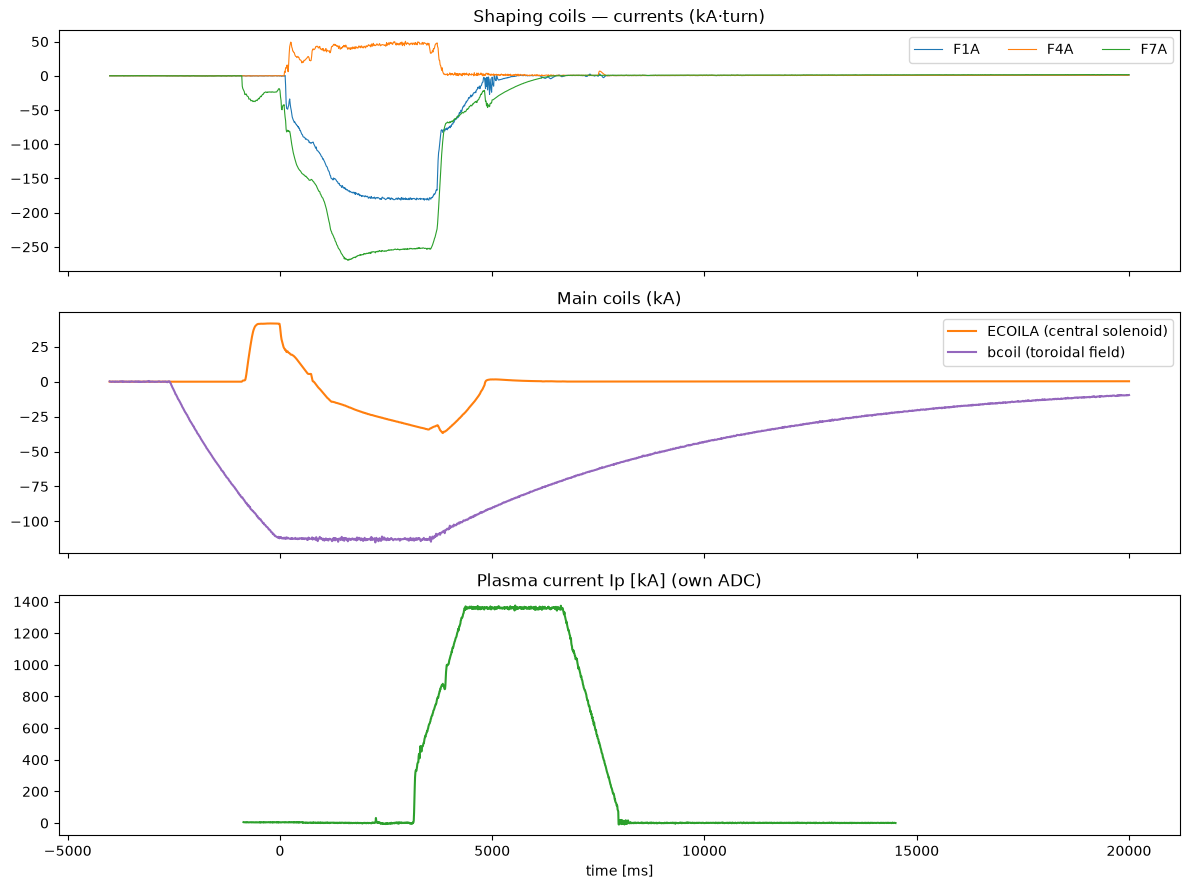

magnetics_time: 480,256 samples, dt≈0.04993 ms
Ip time base:   30,719 samples, dt≈0.5 ms


In [7]:

def downsample(x, n=2000):
    if len(x) <= n:
        return x
    idx = np.linspace(0, len(x) - 1, n).astype(int)
    return np.asarray(x)[idx]

t = d3d["magnetics_time"]
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for i, coil in enumerate(["F1A", "F4A", "F7A"]):
    axes[0].plot(downsample(t), downsample(d3d[f"magnetics_{coil}"]), lw=0.8, label=coil)
axes[0].set_title("Shaping coils — currents (kA·turn)")
axes[0].legend(ncol=3)

axes[1].plot(downsample(t), downsample(d3d["magnetics_ECOILA"]), color="tab:orange", label="ECOILA (central solenoid)")
axes[1].plot(downsample(t), downsample(d3d["magnetics_bcoil"]), color="tab:purple", label="bcoil (toroidal field)")
axes[1].set_title("Main coils (kA)"); axes[1].legend()

ti = d3d["magnetics_plasma_current_times"]
axes[2].plot(downsample(ti), downsample(d3d["magnetics_plasma_current"]), color="tab:green")
axes[2].set_title("Plasma current Ip [kA] (own ADC)")
axes[2].set_xlabel("time [ms]")
plt.tight_layout(); plt.show()

print(f"magnetics_time: {len(t):,} samples, dt≈{np.median(np.diff(t)):.4g} ms")
print(f"Ip time base:   {len(ti):,} samples, dt≈{np.median(np.diff(ti)):.4g} ms")


### DIII-D coil geometry

The `coil_*` columns describe each coil as a conductor rectangle (centre, width/height, and parallelogram shear angles).
DIII-D ships **19 lumped rectangles** — the same representation EFIT's own `mhdin.dat` machine file uses.
Six of the F-coils (`F5A/B`, `F6A/B`, `F7A/B`) are sheared parallelograms (see `coil_angle1/2`).
The `coil_input_column` is the join key back to the current column.


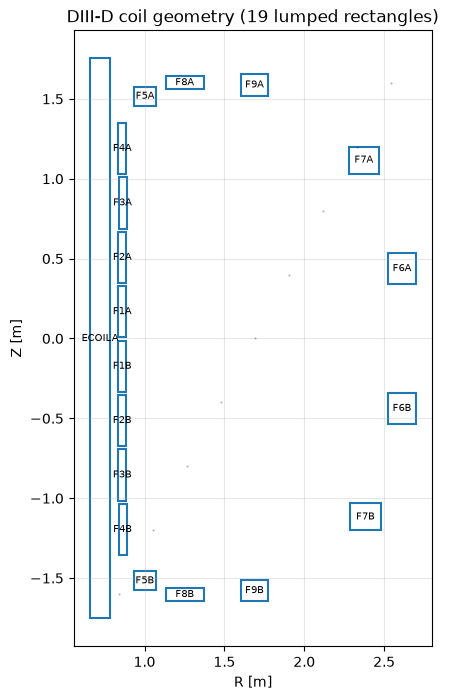

Sheared (parallelogram) coils:
name    a1      a2
 F5A  45.0    0.00
 F6A   0.0   92.40
 F7A   0.0  108.06
 F5B -45.0    0.00
 F6B   0.0  -92.40
 F7B   0.0 -108.06


In [8]:

coil = pd.DataFrame({
    "name": d3d["coil_name"], "col": d3d["coil_input_column"],
    "R": d3d["coil_R"], "Z": d3d["coil_Z"],
    "w": d3d["coil_width"], "h": d3d["coil_height"],
    "a1": d3d["coil_angle1"], "a2": d3d["coil_angle2"],
})
coil[["name", "col", "R", "Z", "w", "h", "a1", "a2"]].to_string(index=False)

fig, ax = plt.subplots(figsize=(7, 8))
for _, c in coil.iterrows():
    rect = plt.Rectangle((c.R - c.w / 2, c.Z - c.h / 2), c.w, c.h, angle=0,
                         facecolor="none", edgecolor="tab:blue", lw=1.5)
    ax.add_patch(rect)
    ax.text(c["R"], c["Z"], c["name"].replace("magnetics_", ""), fontsize=7, ha="center", va="center")
ax.plot(d3d["efit_grid_R"][::8], d3d["efit_grid_Z"][::8], "k.", ms=1, alpha=0.3)  # grid footprint
ax.set_title("DIII-D coil geometry (19 lumped rectangles)")
ax.set_xlabel("R [m]"); ax.set_ylabel("Z [m]")
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
plt.show()

print("Sheared (parallelogram) coils:")
print(coil.loc[coil[["a1", "a2"]].abs().sum(axis=1) > 0, ["name", "a1", "a2"]].to_string(index=False))


## 5. Magnetics — the actuators (MAST)

MAST is a **spherical tokamak**: narrower central column, different coil set (10 poloidal P-coils `P2`–`P6` lower/upper — no P1/P7/P8/P9),
plus `Solenoid`, `TF`, `EFPS`, and `Ip`. It also ships **one `magnetics_time` base**, but here at 0.2 ms / 5 kHz (30,000 samples).

> ⚠️ **Unit conventions differ from DIII-D — and not by one factor.** MAST currents are in **kA** (`ip`, `tf`, `sol`, `efps`),
> the ten P-coils are **kA·turn**, and their true per-turn ampere conversion needs the turn counts from the `coil_*` geometry
> (P2 = 20, P3 = 8, P4 = 23, P5 = 23, P6 = 4, Solenoid = 656).


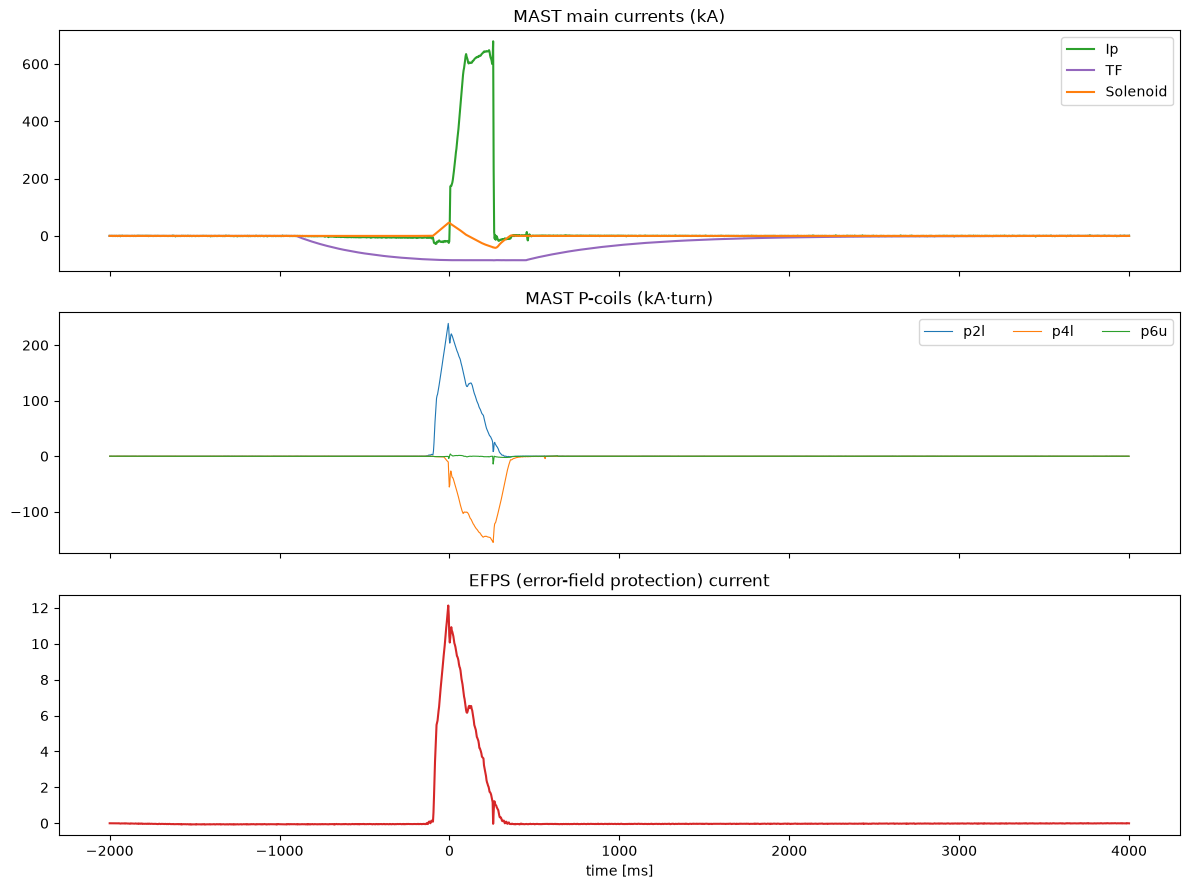

MAST magnetics_time: 30,000 samples, dt≈0.2 ms


In [9]:

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
t = mast["magnetics_time"]

axes[0].plot(downsample(t), downsample(mast["magnetics_ip_current"] if "magnetics_ip_current" in mast.index else mast["magnetics_plasma_current"]), color="tab:green", label="Ip")
axes[0].plot(downsample(t), downsample(mast["magnetics_tf_current"]), color="tab:purple", label="TF")
axes[0].plot(downsample(t), downsample(mast["magnetics_sol_current"]), color="tab:orange", label="Solenoid")
axes[0].set_title("MAST main currents (kA)"); axes[0].legend()

for coil in ["p2l", "p4l", "p6u"]:
    axes[1].plot(downsample(t), downsample(mast[f"magnetics_{coil}_current"]), lw=0.8, label=coil)
axes[1].set_title("MAST P-coils (kA·turn)"); axes[1].legend(ncol=3)

axes[2].plot(downsample(t), downsample(mast["magnetics_efps_current"]), color="tab:red")
axes[2].set_title("EFPS (error-field protection) current"); axes[2].set_xlabel("time [ms]")
plt.tight_layout(); plt.show()

print(f"MAST magnetics_time: {len(t):,} samples, dt≈{np.median(np.diff(t)):.4g} ms")


### MAST coil geometry — conductor-element granularity

MAST ships **C = 812 individual conductor elements** from the FAIR level-2 `pf_active` IDS — one row per conductor turn.
The solenoid alone is 656 of them. Several elements share one current column; the number of rows per column **is** the turn count.


MAST turns per current column:
col
magnetics_sol_current    656
magnetics_p4l_current     23
magnetics_p4u_current     23
magnetics_p5l_current     23
magnetics_p5u_current     23
magnetics_p2l_current     20
magnetics_p2u_current     20
magnetics_p3l_current      8
magnetics_p3u_current      8
magnetics_p6l_current      4
magnetics_p6u_current      4


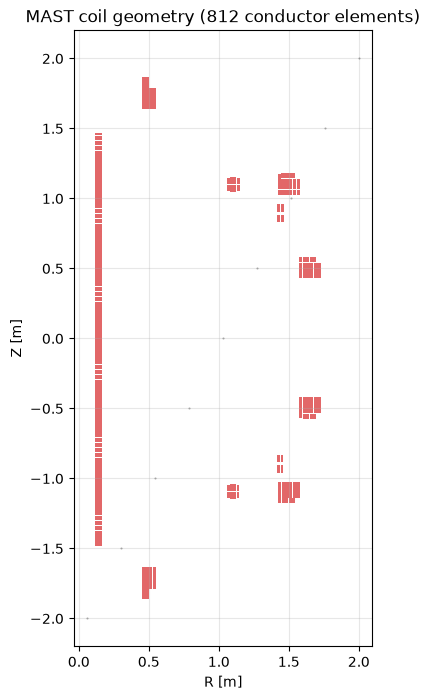

In [10]:

mcoil = pd.DataFrame({
    "col": mast["coil_input_column"], "R": mast["coil_R"], "Z": mast["coil_Z"],
    "w": mast["coil_width"], "h": mast["coil_height"],
})
turns = mcoil.groupby("col").size().sort_values(ascending=False)
print("MAST turns per current column:")
print(turns.to_string())

fig, ax = plt.subplots(figsize=(7, 8))
for _, c in mcoil.iterrows():
    rect = plt.Rectangle((c.R - c.w / 2, c.Z - c.h / 2), c.w, c.h,
                         facecolor="tab:red", edgecolor="none", alpha=0.7)
    ax.add_patch(rect)
ax.plot(mast["efit_grid_R"][::8], mast["efit_grid_Z"][::8], "k.", ms=1, alpha=0.3)
ax.set_title("MAST coil geometry (812 conductor elements)")
ax.set_xlabel("R [m]"); ax.set_ylabel("Z [m]")
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
plt.show()


## 6. Thomson scattering — the kinetic sensors

Thomson scattering measures electron **temperature `Te`** (eV) and **density `ne`** (m⁻³) at discrete spatial channels, at a
lower cadence than magnetics. Two subsystems per machine:

| Subsystem | DIII-D | MAST |
|---|---|---|
| **core** (vertical) | `thomson_core_R` ≈ 1.94 m constant; channels vary in **Z** (not shipped per-channel) | per-channel **R** ≈ 0.25–1.5 m |
| **edge** (tangential) | `thomson_edge_spatial` is **Z** (≈ −0.05 m) | `thomson_edge_spatial` is **R** (≈ 1.3–1.5 m) |

Each machine gives a *single spatial axis* per system, so the chord positions are machine-specific — see the `thomson_chord_*`
columns which give full (R, Z) per channel and close this gap.


/var/folders/dw/64ttvnhd2r34sg0qn_2qh0c80000gn/T/ipykernel_29284/213368805.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  for a in axes.ravel(): a.legend(fontsize=8)


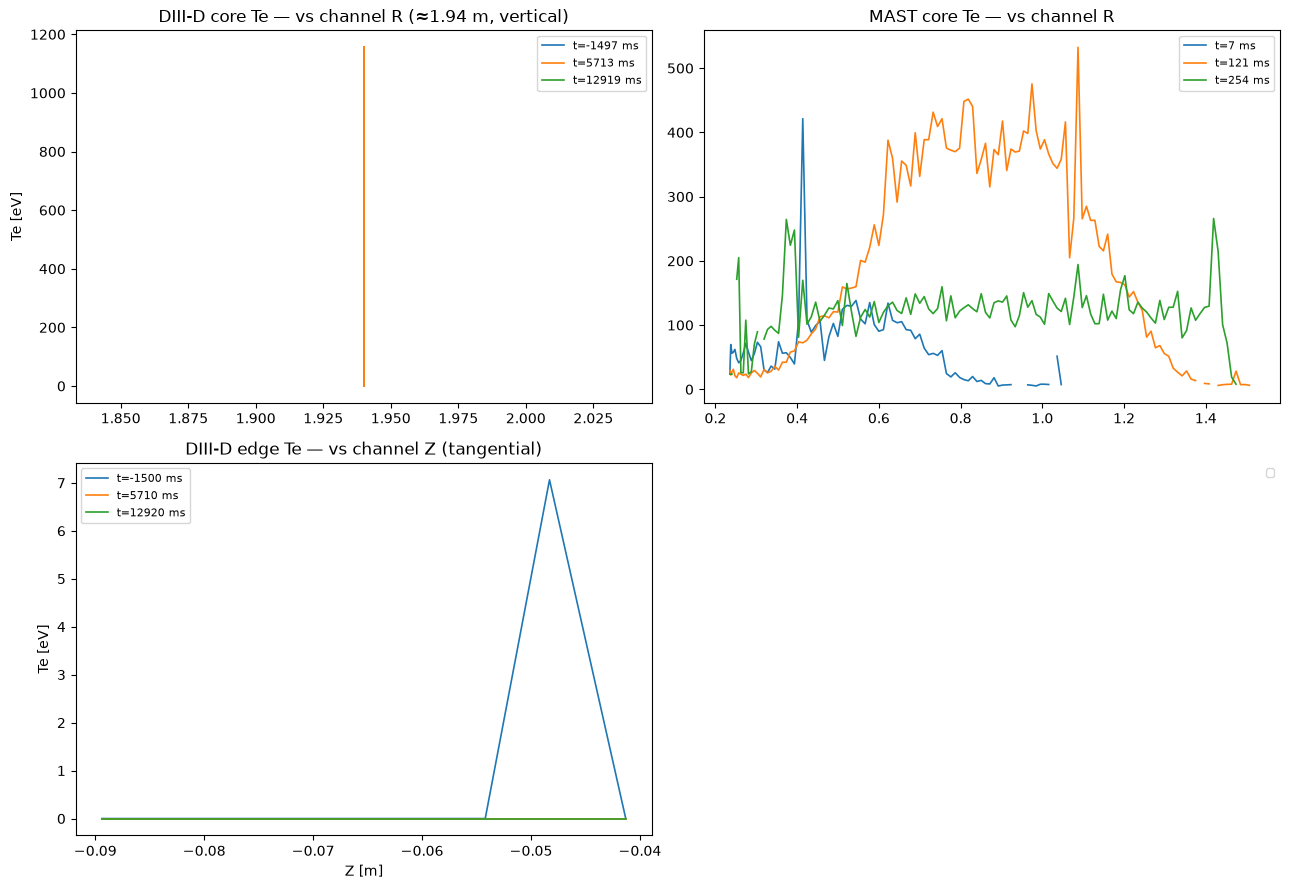

DIII-D core channels: 42   MAST core channels: 131   DIII-D edge channels: 14
DIII-D core times: 3029   edge times: 1443


In [11]:

# Core profiles at 3 times, both machines
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

core_te_d = stack_profiles(d3d["thomson_core_Te"])   # (T, C)
core_te_m = stack_profiles(mast["thomson_core_Te"])
edge_te_d = stack_profiles(d3d["thomson_edge_Te"])

idx_d = np.linspace(0, core_te_d.shape[0] - 1, 3).astype(int)
idx_m = np.linspace(0, core_te_m.shape[0] - 1, 3).astype(int)
idx_e = np.linspace(0, edge_te_d.shape[0] - 1, 3).astype(int)
for j in range(3):
    n_c = min(len(d3d["thomson_core_R"]), core_te_d.shape[1])
    axes[0, 0].plot(d3d["thomson_core_R"][:n_c], core_te_d[idx_d[j]][:n_c], lw=1.2, label=f"t={d3d['thomson_core_times'][idx_d[j]]:.0f} ms")
    n_m = min(len(mast["thomson_core_R"]), core_te_m.shape[1])
    axes[0, 1].plot(mast["thomson_core_R"][:n_m], core_te_m[idx_m[j]][:n_m], lw=1.2, label=f"t={mast['thomson_core_times'][idx_m[j]]:.0f} ms")
    n_e = min(len(d3d["thomson_edge_spatial"]), edge_te_d.shape[1])
    axes[1, 0].plot(d3d["thomson_edge_spatial"][:n_e], edge_te_d[idx_e[j]][:n_e], lw=1.2, label=f"t={d3d['thomson_edge_times'][idx_e[j]]:.0f} ms")

axes[0, 0].set_title("DIII-D core Te — vs channel R (≈1.94 m, vertical)"); axes[0, 0].set_ylabel("Te [eV]")
axes[0, 1].set_title("MAST core Te — vs channel R")
axes[1, 0].set_title("DIII-D edge Te — vs channel Z (tangential)"); axes[1, 0].set_ylabel("Te [eV]"); axes[1, 0].set_xlabel("Z [m]")
axes[1, 1].axis("off")
for a in axes.ravel(): a.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"DIII-D core channels: {core_te_d.shape[1]}   MAST core channels: {core_te_m.shape[1]}   DIII-D edge channels: {edge_te_d.shape[1]}")
print(f"DIII-D core times: {len(d3d['thomson_core_times'])}   edge times: {len(d3d['thomson_edge_times'])}")


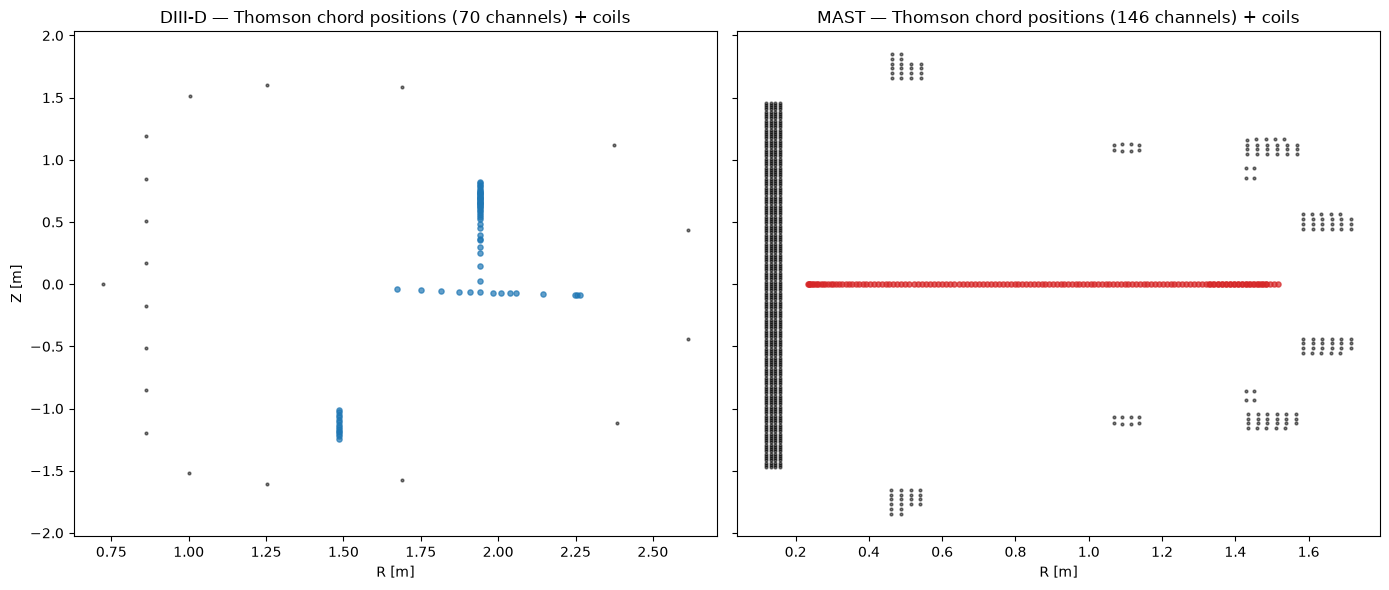

In [12]:

# Full chord positions (R, Z) for every channel, both machines
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, (row, name, col) in zip(axes, [
    (d3d, "DIII-D", "tab:blue"), (mast, "MAST", "tab:red")]):
    ax.scatter(row["thomson_chord_R"], row["thomson_chord_Z"], s=14, color=col, alpha=0.7)
    ax.scatter(row["coil_R"], row["coil_Z"], s=4, color="k", alpha=0.5)
    ax.set_title(f"{name} — Thomson chord positions ({len(row['thomson_chord_R'])} channels) + coils")
    ax.set_xlabel("R [m]")
axes[0].set_ylabel("Z [m]")
plt.tight_layout(); plt.show()


## 7. DIII-D vs MAST — the conventions that will bite you

| | DIII-D | MAST |
|---|---|---|
| Flux grid R | 0.84 → 2.54 m | 0.06 → 2.0 m |
| Flux grid Z | −1.6 → 1.6 m | −2.0 → 2.0 m |
| ψ sign of magnetic axis | **minimum** | **maximum** |
| Magnetics cadence | 20 kHz (480,256 pts), Ip on own 2 kHz ADC | 5 kHz (30,000 pts), two time-base populations |
| Coil granularity | 19 lumped rectangles | 812 conductor elements |
| Current units | `F*` kA·turn; `ECOILA`/`bcoil`/`Ip` kA | P-coils kA·turn; `ip`/`tf`/`sol`/`efps` kA |
| Thomson core | R const ≈ 1.94 m | per-channel R |
| Thomson edge | Z ≈ −0.05 m | R ≈ 1.3–1.5 m |

A DIII-D-trained model applied to MAST predicts the correct equilibrium with the **wrong global sign**. Always check `R²(−ψ_pred)` on MAST.
The scorer is sign-invariant (it picks the better global sign per machine), so you are not graded on guessing a storage convention.


## 8. From raw signals to model features

The starter kit (`experiments.py`) turns these nested arrays into a flat design matrix:

1. **Interpolate** every input onto `efit_times` (the target timestamps) — magnetics are dense, Thomson are sparse.
2. **Stack** the 21 DIII-D magnetics channels → `(T, 21)`; optionally add interpolated Thomson channels.
3. **Scale** (input ranges span ~10³ A to ~10⁶ A) and **PCA-compress the 65×65 ψ targets** before regression.

Here is the interpolation step for one magnetics channel:


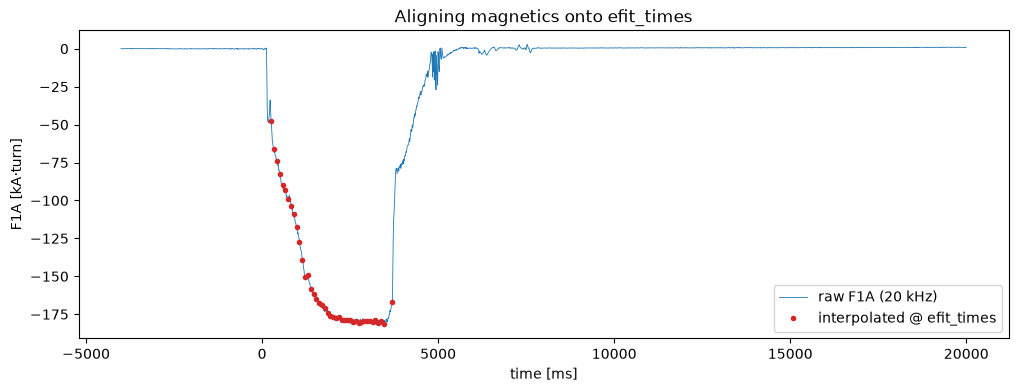

efit_times: T=166  (first 3: [260. 280. 300.])


In [13]:

from scipy.interpolate import interp1d

ef = d3d["efit_times"]
f = interp1d(d3d["magnetics_time"], d3d["magnetics_F1A"],
             kind="linear", fill_value="extrapolate", bounds_error=False)
f1a_at_efit = f(ef)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(downsample(d3d["magnetics_time"]), downsample(d3d["magnetics_F1A"]), lw=0.6, label="raw F1A (20 kHz)")
ax.plot(ef[::4], f1a_at_efit[::4], "o", ms=3, color="tab:red", label="interpolated @ efit_times")
ax.set_xlabel("time [ms]"); ax.set_ylabel("F1A [kA·turn]"); ax.legend(); ax.set_title("Aligning magnetics onto efit_times")
plt.show()
print(f"efit_times: T={len(ef)}  (first 3: {ef[:3]})")


## 9. Next steps

- **Run the baselines:** `uv run python experiments.py --quick` (or `--n-shots 50 --epochs 50` for something real).
- **Score yourself with the real metric** on held-out training shots: `uv run python local_score.py --n-shots 20 --skip 7000`
  — this uses the *actual* competition scorer (R²ψ, D_LCFS, and the 7-scalar Consistency term), vendored in `fusion_scoring/`.
- **Read `MODELING_GUIDE.md`** for the ML walkthrough: feature engineering, the PCA-on-ψ baseline, and normalization advice.
- **Be careful on MAST:** sign convention, kA vs kA·turn, and the two time-base populations (some shots have per-column NaNs).


---

*This notebook uses the 6 local demo shots in `parquet_data/`. The `efit_*` ground truth shown here is **withheld on the real test splits** —
it exists in the demo files purely so you can understand the target.*
